In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# **Dataset**

In [5]:
df = pd.read_csv("WorldSustainabilityDataset.csv")
df.head()

,Country Name,Country Code,Year,Access to electricity (% of population) - EG.ELC.ACCS.ZS,Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG,"Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS",Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS,Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS,Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS,Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS,...,Gini index (World Bank estimate) - SI.POV.GINI,Income Classification (World Bank Definition),Individuals using the Internet (% of population) - IT.NET.USER.ZS,"Life expectancy at birth, total (years) - SP.DYN.LE00.IN","Population, total - SP.POP.TOTL",Regime Type (RoW Measure Definition),Rural population (% of total population) - SP.RUR.TOTL.ZS,Total natural resources rents (% of GDP) - NY.GDP.TOTL.RT.ZS,Urban population (% of total population) - SP.URB.TOTL.IN.ZS,World Regions (UN SDG Definition)
0,Aruba,ABW,2000,91.660398,NaN,15.392211,2.389134,0.000190,0.000190,NaN,...,NaN,High income,NaN,NaN,NaN,NaN,53.283,NaN,NaN,Latin America and Caribbean
1,Aruba,ABW,2001,100.000000,NaN,11.491930,2.509046,0.000214,0.000214,NaN,...,NaN,High income,17.1,73.853,92892.0,NaN,53.661,0.000712,46.339,Latin America and Caribbean
2,Aruba,ABW,2002,100.000000,NaN,3.893620,2.721385,0.000223,0.000223,NaN,...,NaN,High income,18.8,73.937,94992.0,NaN,54.028,0.000657,45.972,Latin America and Caribbean
3,Aruba,ABW,2003,100.000000,NaN,6.713863,2.733676,0.000243,0.000243,NaN,...,NaN,High income,20.8,74.038,97016.0,NaN,54.394,0.000700,45.606,Latin America and Caribbean
4,Aruba,ABW,2004,100.000000,NaN,9.801576,2.678363,0.000256,0.000256,NaN,...,NaN,High income,23.0,74.156,98744.0,NaN,54.760,0.000685,45.240,Latin America and Caribbean


# **Dropping unnecessary columns**

In [7]:
df = df[[
    "Access to electricity (% of population) - EG.ELC.ACCS.ZS",
    "GDP per capita (current US$) - NY.GDP.PCAP.CD",
    "Renewable electricity output (% of total electricity output) - EG.ELC.RNEW.ZS",
    "Renewable energy consumption (% of total final energy consumption) - EG.FEC.RNEW.ZS",
    "Annual production-based emissions of carbon dioxide (CO2), measured in million tonnes",
    "Life expectancy at birth, total (years) - SP.DYN.LE00.IN"
]]

df.head()

,Access to electricity (% of population) - EG.ELC.ACCS.ZS,GDP per capita (current US$) - NY.GDP.PCAP.CD,Renewable electricity output (% of total electricity output) - EG.ELC.RNEW.ZS,Renewable energy consumption (% of total final energy consumption) - EG.FEC.RNEW.ZS,"Annual production-based emissions of carbon dioxide (CO2), measured in million tonnes","Life expectancy at birth, total (years) - SP.DYN.LE00.IN"
0,91.660398,20617.75047,0.0,0.1753,2.378,NaN
1,100.000000,20670.36701,0.0,0.1805,2.407,73.853
2,100.000000,20436.88713,0.0,0.1814,2.437,73.937
3,100.000000,20833.97636,0.0,0.1846,2.561,74.038
4,100.000000,22568.37499,0.0,0.1871,2.616,74.156


# **Checking missing values**

In [8]:
df.isnull().sum()

,0
Access to electricity (% of population) - EG.ELC.ACCS.ZS,94
GDP per capita (current US$) - NY.GDP.PCAP.CD,41
Renewable electricity output (% of total electricity output) - EG.ELC.RNEW.ZS,516
Renewable energy consumption (% of total final energy consumption) - EG.FEC.RNEW.ZS,0
"Annual production-based emissions of carbon dioxide (CO2), measured in million tonnes",2
"Life expectancy at birth, total (years) - SP.DYN.LE00.IN",191


# **Handling missing values**

In [10]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
Access to electricity (% of population) - EG.ELC.ACCS.ZS,0
GDP per capita (current US$) - NY.GDP.PCAP.CD,0
Renewable electricity output (% of total electricity output) - EG.ELC.RNEW.ZS,0
Renewable energy consumption (% of total final energy consumption) - EG.FEC.RNEW.ZS,0
"Annual production-based emissions of carbon dioxide (CO2), measured in million tonnes",0
"Life expectancy at birth, total (years) - SP.DYN.LE00.IN",0


# **Visualization**

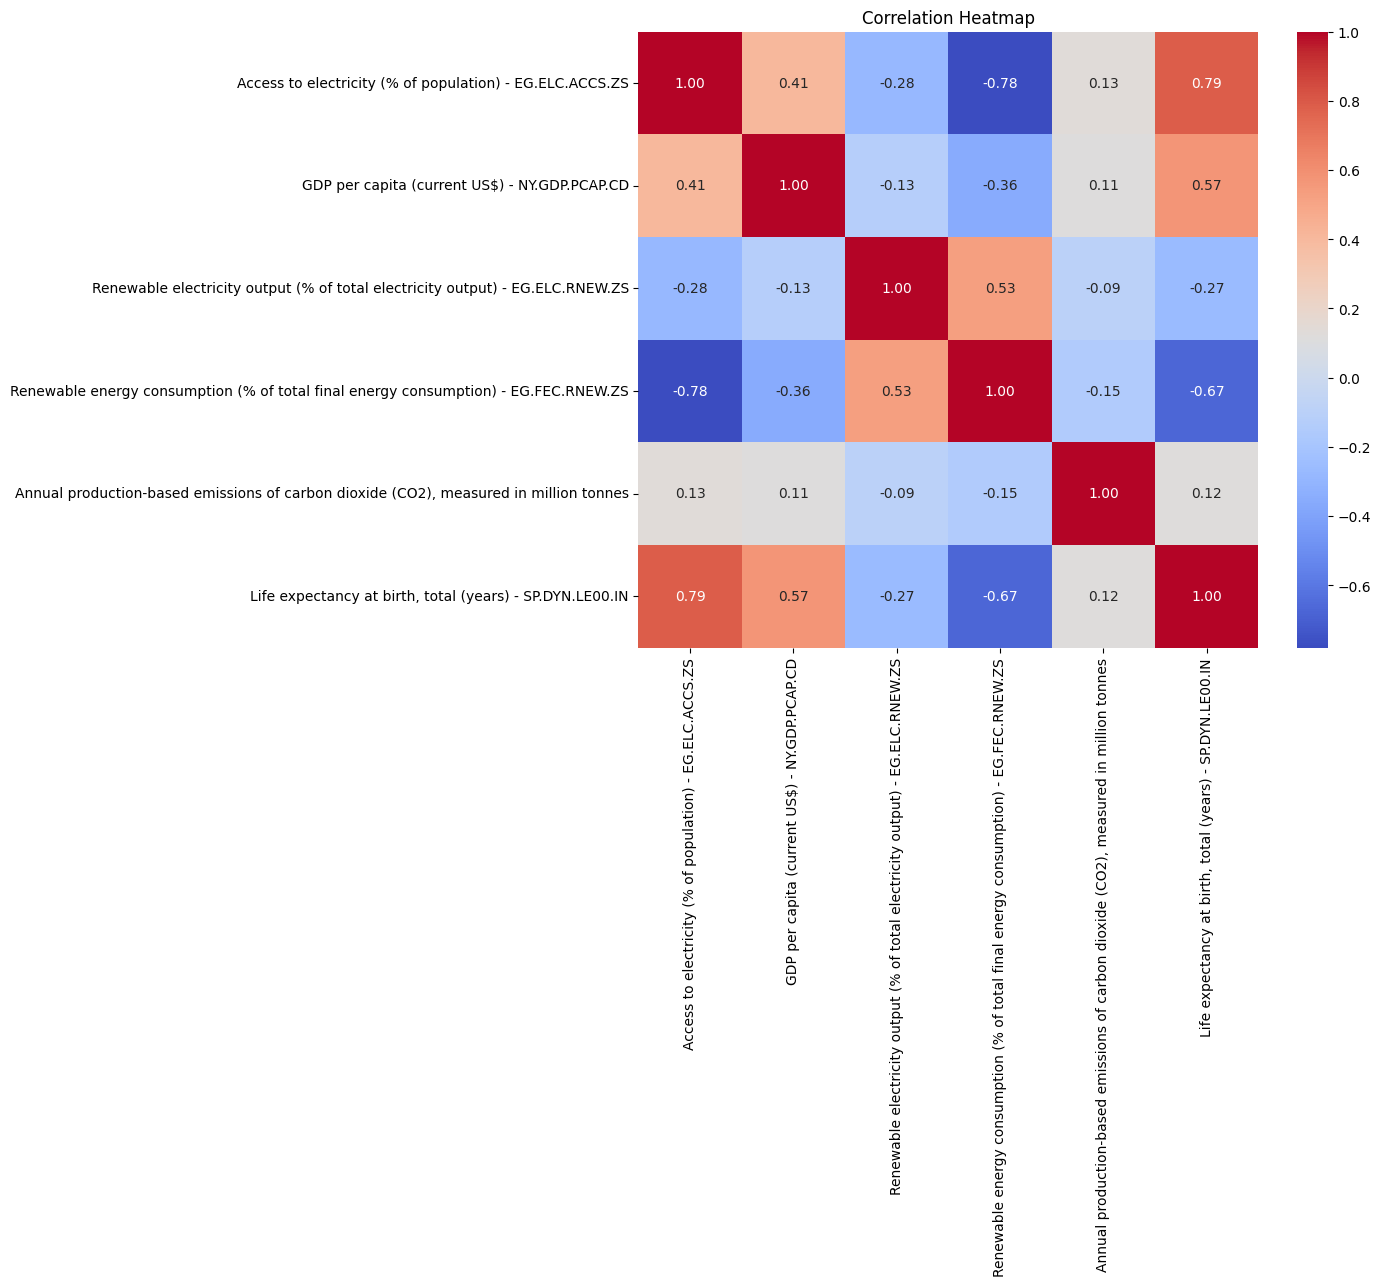

In [11]:
#heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

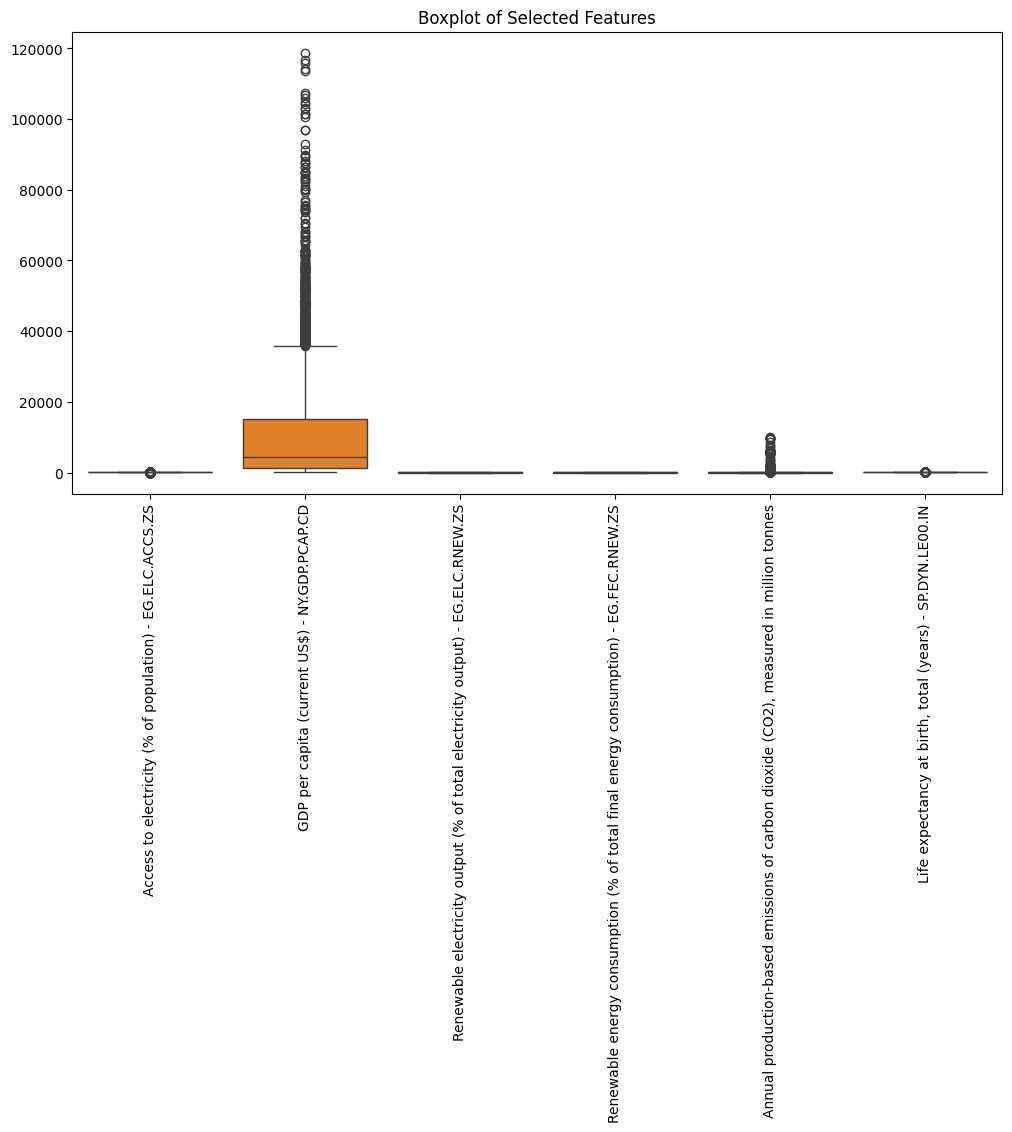

In [12]:
#boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Selected Features")
plt.show()

# **feature scaling**

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# **elbow method**

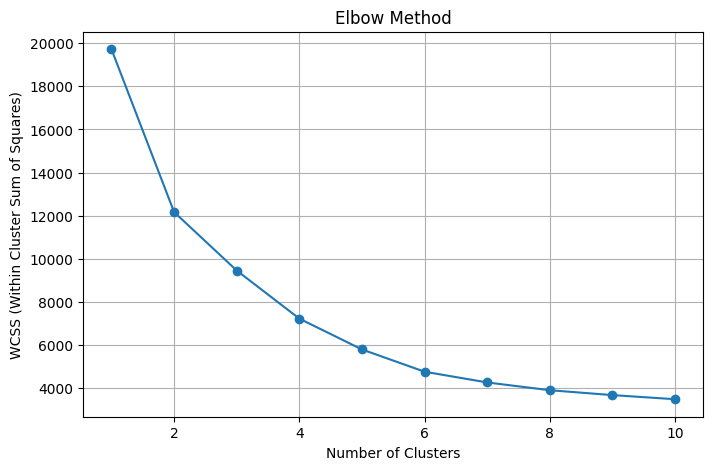

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within Cluster Sum of Squares)")

plt.grid(True)
plt.show()

# **Applying kmeans**

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

print(df["Cluster"].value_counts())

Cluster
0    2329
1     922
2      36
Name: count, dtype: int64


# **Cluster visualization**

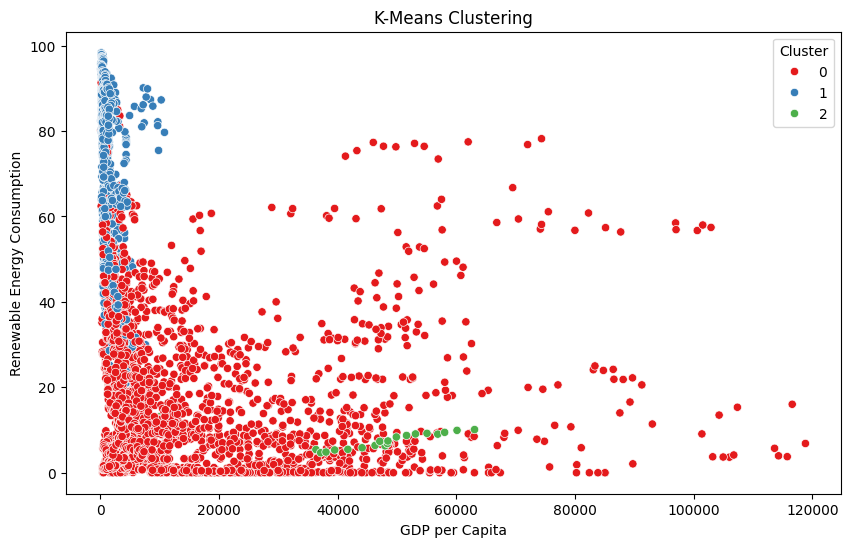

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["GDP per capita (current US$) - NY.GDP.PCAP.CD"],
    y=df["Renewable energy consumption (% of total final energy consumption) - EG.FEC.RNEW.ZS"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("K-Means Clustering")
plt.xlabel("GDP per Capita")
plt.ylabel("Renewable Energy Consumption")
plt.legend(title="Cluster")

plt.show()

# **Insights**

- The dataset was cleaned by handling missing values using the median.
- Six important sustainability indicators were selected for clustering.
- Feature scaling was applied because K-Means is a distance-based algorithm.
- The Elbow Method was used to determine the optimal number of clusters.
- K-Means Clustering grouped countries based on similarities in sustainability indicators.
- The Silhouette Score was used to evaluate the quality of the clusters.
- The resulting clusters can help identify groups of countries with similar environmental, economic, and energy characteristics.